# Fine-Tuning for Exposure Restoration

In [ ]:
!gdown 1Nb7geOuhASq1-vuK3enytyDU9mgjsGFz

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1Nb7geOuhASq1-vuK3enytyDU9mgjsGFz

but Gdown can't. Please check connections and permissions.


In [ ]:
!unzip subset.zip

Archive:  subset.zip
replace subset/classification_labels.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Imports

In [ ]:
import os
import math
import random
import numpy as np
import pandas as pd

from tqdm import tqdm
import cv2
from PIL import Image
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

import numbers
from einops import rearrange


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


## Dataset Overview

The dataset consists of paired image frames extracted from video sequences.  
Each degraded frame affected by **exposure** is paired with its corresponding **clean (no_challenge)** frame from the same sequence and frame index.

This pairing ensures:
- Perfect spatial alignment
- Supervised learning with pixel-level correspondence
- Controlled degradation-specific adaptation

---

## Frame Parsing and Pair Construction

Each image filename encodes metadata such as:
- Sequence ID
- Challenge type (e.g., rain)
- Corruption level
- Frame index

This information is parsed directly from filenames to:
- Match degraded and clean frames
- Preserve temporal consistency
- Separate training and test splits correctly



In [ ]:
import pandas as pd

df = pd.read_csv("subset/classification_labels.csv")


In [ ]:
def parse_frame_info(path):
    name = os.path.basename(path).replace(".jpg", "")
    _, seq, ctype, clevel, frame = name.split("_")
    return seq, int(frame)

df["seq"], df["frame_idx"] = zip(*df["frame"].map(parse_frame_info))
df["split"] = df["frame"].apply(
    lambda x: "test" if "/test/" in x else "train"
)


In [ ]:
def build_pairs(df, expert_name):
    clean = df[df.challenge == "no_challenge"]
    degraded = df[df.challenge == expert_name]

    pairs = degraded.merge(
        clean,
        on=["seq", "frame_idx", "split"],
        suffixes=("_deg", "_clean")
    )

    return pairs


## Dataset Splitting Strategy

The paired dataset is divided into:
- **Training set** – used for optimization
- **Validation set** – used for early stopping and model selection
- **Test set** – held out for final evaluation

A validation split is applied only to the training portion to ensure fair evaluation.

In [ ]:


def split_pairs(pairs, val_ratio=0.1, seed=42):
    train_pairs = pairs[pairs.split == "train"].reset_index(drop=True)
    test_pairs  = pairs[pairs.split == "test"].reset_index(drop=True)

    train_pairs, val_pairs = train_test_split(
        train_pairs,
        test_size=val_ratio,
        random_state=seed,
        shuffle=True
    )

    return train_pairs, val_pairs, test_pairs


## Patch-Based Training

During training and validation:
- Random crops are extracted from input–target pairs
- Cropping improves memory efficiency
- Encourages spatial generalization

During testing:
- Full-resolution images are preserved
- No random cropping is applied

In [ ]:
def random_crop_pair(inp, tgt, crop_size=256):
    w, h = inp.size

    if w < crop_size or h < crop_size:
        return inp, tgt  # fallback

    x = random.randint(0, w - crop_size)
    y = random.randint(0, h - crop_size)

    inp = inp.crop((x, y, x + crop_size, y + crop_size))
    tgt = tgt.crop((x, y, x + crop_size, y + crop_size))

    return inp, tgt


## Padding Strategy for Inference

Transformer-based restoration models require spatial dimensions divisible by 8.  
To satisfy this constraint:
- Images are padded using **reflection padding**
- Padding avoids introducing artificial borders
- Outputs are cropped back to original size after inference

In [ ]:

def pad_to_multiple_of_8(img_tensor):
    """
    img_tensor: (B, C, H, W) or (C, H, W)
    Returns padded tensor + original size
    """
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)

    _, _, h, w = img_tensor.shape

    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8

    padded = F.pad(
        img_tensor,
        (0, pad_w, 0, pad_h),  # (left, right, top, bottom)
        mode="reflect"         # IMPORTANT: no black borders
    )

    return padded, (h, w)


## Data Loader Design

Custom PyTorch datasets return:
- Degraded input image
- Clean target image
- Image filename (for saving and visualization)

Data loaders use:
- Small batch sizes
- Pin memory for faster GPU transfers
- Deterministic shuffling for reproducibility


In [ ]:

class RestorationDataset(Dataset):

    def __init__(self, pairs_df, split="train", crop_size=384, max_test_side=512):
        self.df = pairs_df.reset_index(drop=True)
        self.split = split
        self.crop_size = crop_size
        self.max_test_side = max_test_side
        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        inp = Image.open(row["frame_deg"]).convert("RGB")
        tgt = Image.open(row["frame_clean"]).convert("RGB")

        if self.split == "train":
            inp, tgt = random_crop_pair(inp, tgt, self.crop_size)

        elif self.split == "val":
            inp, tgt = center_crop_pair(inp, tgt, self.crop_size)


        return {
            "input": self.to_tensor(inp),
            "target": self.to_tensor(tgt),
            "name": os.path.basename(row["frame_deg"])
        }

In [ ]:
exposure_pairs = build_pairs(df, "exposure")
train_p, val_p, test_p = split_pairs(exposure_pairs, val_ratio=0.4)


In [ ]:
train_ds = RestorationDataset(train_p,"train")
val_ds   = RestorationDataset(val_p,"val")
test_ds  = RestorationDataset(test_p,"test")

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False
)


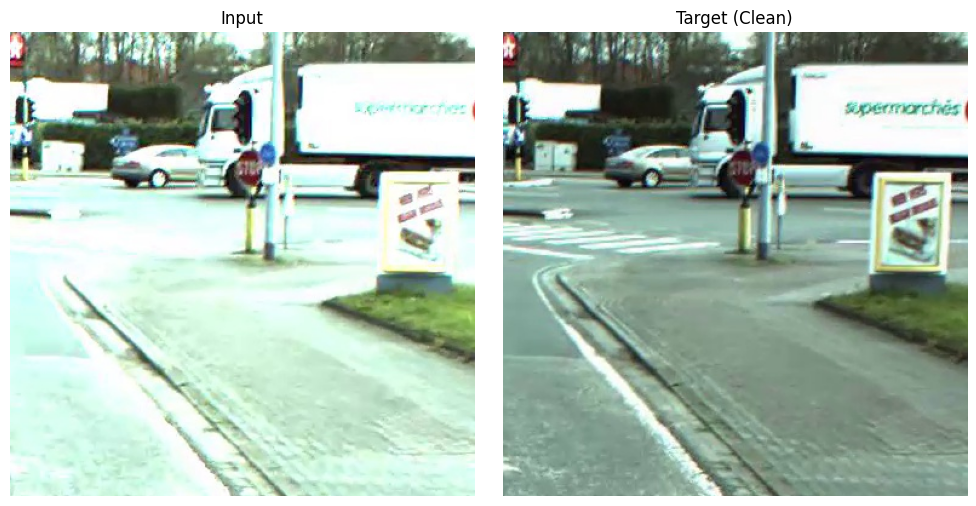

In [ ]:
batch = next(iter(train_loader))

inp = batch["input"][0]     # [C,H,W]
tgt = batch["target"][0]


inp_img = T.functional.to_pil_image(inp)
tgt_img = T.functional.to_pil_image(tgt)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(inp_img)
plt.title(f"Input")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(tgt_img)
plt.title("Target (Clean)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Restormer Architecture

The restoration backbone is **Restormer**, a transformer optimized for low-level vision tasks.

Key components include:
- Overlapping patch embedding
- Multi-DConv Head Transposed Attention (MDTA)
- Gated Depthwise Feed-Forward Networks (GDFN)
- Multi-scale encoder–decoder structure
- Refinement blocks for high-frequency details

This architecture balances global context modeling with local detail preservation.

In [ ]:
# Layer Norm helpers

def to_3d(x):
    return rearrange(x, 'b c h w -> b (h w) c')

def to_4d(x, h, w):
    return rearrange(x, 'b (h w) c -> b c h w', h=h, w=w)

class BiasFree_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)
        assert len(normalized_shape) == 1
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x):
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return x / torch.sqrt(sigma + 1e-5) * self.weight

class WithBias_LayerNorm(nn.Module):
    def __init__(self, normalized_shape):
        super().__init__()
        if isinstance(normalized_shape, numbers.Integral):
            normalized_shape = (normalized_shape,)
        normalized_shape = torch.Size(normalized_shape)
        assert len(normalized_shape) == 1
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))

    def forward(self, x):
        mu = x.mean(-1, keepdim=True)
        sigma = x.var(-1, keepdim=True, unbiased=False)
        return (x - mu) / torch.sqrt(sigma + 1e-5) * self.weight + self.bias

class LayerNorm(nn.Module):
    def __init__(self, dim, LayerNorm_type='WithBias'):
        super().__init__()
        self.body = BiasFree_LayerNorm(dim) if LayerNorm_type == 'BiasFree' else WithBias_LayerNorm(dim)

    def forward(self, x):
        h, w = x.shape[-2:]
        return to_4d(self.body(to_3d(x)), h, w)

In [ ]:
# Gated-Dconv Feed-Forward Network (GDFN)

class FeedForward(nn.Module):
    def __init__(self, dim, ffn_expansion_factor=2.66, bias=False):
        super().__init__()
        hidden_features = int(dim * ffn_expansion_factor)
        self.project_in  = nn.Conv2d(dim, hidden_features * 2, 1, bias=bias)
        self.dwconv      = nn.Conv2d(hidden_features * 2, hidden_features * 2, 3, 1, 1,
                                     groups=hidden_features * 2, bias=bias)
        self.project_out = nn.Conv2d(hidden_features, dim, 1, bias=bias)

    def forward(self, x):
        x = self.project_in(x)
        x1, x2 = self.dwconv(x).chunk(2, dim=1)
        x = F.gelu(x1) * x2
        return self.project_out(x)



In [ ]:
# Multi-DConv Head Transposed Self-Attention (MDTA)

class Attention(nn.Module):
    def __init__(self, dim, num_heads=1, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1))

        self.qkv        = nn.Conv2d(dim, dim * 3, 1, bias=bias)
        self.qkv_dwconv = nn.Conv2d(dim * 3, dim * 3, 3, 1, 1, groups=dim * 3, bias=bias)
        self.project_out = nn.Conv2d(dim, dim, 1, bias=bias)

    def forward(self, x):
        b, c, h, w = x.shape

        qkv = self.qkv_dwconv(self.qkv(x))
        q, k, v = qkv.chunk(3, dim=1)

        q = rearrange(q, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        k = rearrange(k, 'b (head c) h w -> b head c (h w)', head=self.num_heads)
        v = rearrange(v, 'b (head c) h w -> b head c (h w)', head=self.num_heads)

        q = F.normalize(q, dim=-1)
        k = F.normalize(k, dim=-1)

        attn = (q @ k.transpose(-2, -1)) * self.temperature
        attn = attn.softmax(dim=-1)

        out = (attn @ v)
        out = rearrange(out, 'b head c (h w) -> b (head c) h w', head=self.num_heads, h=h, w=w)

        return self.project_out(out)


In [ ]:
# Transformer Block

class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, ffn_expansion_factor=2.66, bias=False, LayerNorm_type='WithBias'):
        super().__init__()
        self.norm1 = LayerNorm(dim, LayerNorm_type)
        self.attn  = Attention(dim, num_heads, bias)
        self.norm2 = LayerNorm(dim, LayerNorm_type)
        self.ffn   = FeedForward(dim, ffn_expansion_factor, bias)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


In [ ]:
# Overlapped patch embed

class OverlapPatchEmbed(nn.Module):
    def __init__(self, in_c=3, embed_dim=48, bias=False):
        super().__init__()
        self.proj = nn.Conv2d(in_c, embed_dim, 3, 1, 1, bias=bias)

    def forward(self, x):
        return self.proj(x)


In [ ]:
# Down/Up sample

class Downsample(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat // 2, 3, 1, 1, bias=False),
            nn.PixelUnshuffle(2)
        )

    def forward(self, x):
        return self.body(x)

class Upsample(nn.Module):
    def __init__(self, n_feat):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(n_feat, n_feat * 2, 3, 1, 1, bias=False),
            nn.PixelShuffle(2)
        )

    def forward(self, x):
        return self.body(x)

In [ ]:
# Restormer

class Restormer(nn.Module):
    def __init__(
        self,
        inp_channels=3,
        out_channels=3,
        dim=48,
        num_blocks=[4,6,6,8],
        num_refinement_blocks=4,
        heads=[1,2,4,8],
        ffn_expansion_factor=2.66,
        bias=False,
        LayerNorm_type='WithBias',
        dual_pixel_task=False
    ):
        super().__init__()

        self.patch_embed = OverlapPatchEmbed(inp_channels, dim)

        self.encoder_level1 = nn.Sequential(*[
            TransformerBlock(dim, heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[0])
        ])

        self.down1_2 = Downsample(dim)
        self.encoder_level2 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[1], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[1])
        ])

        self.down2_3 = Downsample(int(dim*2**1))
        self.encoder_level3 = nn.Sequential(*[
            TransformerBlock(int(dim*2**2), heads[2], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[2])
        ])

        self.down3_4 = Downsample(int(dim*2**2))
        self.latent = nn.Sequential(*[
            TransformerBlock(int(dim*2**3), heads[3], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[3])
        ])

        self.up4_3 = Upsample(int(dim*2**3))
        self.reduce_chan_level3 = nn.Conv2d(int(dim*2**3), int(dim*2**2), 1, bias=bias)
        self.decoder_level3 = nn.Sequential(*[
            TransformerBlock(int(dim*2**2), heads[2], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[2])
        ])

        self.up3_2 = Upsample(int(dim*2**2))
        self.reduce_chan_level2 = nn.Conv2d(int(dim*2**2), int(dim*2**1), 1, bias=bias)
        self.decoder_level2 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[1], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[1])
        ])

        self.up2_1 = Upsample(int(dim*2**1))
        self.decoder_level1 = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_blocks[0])
        ])

        self.refinement = nn.Sequential(*[
            TransformerBlock(int(dim*2**1), heads[0], ffn_expansion_factor, bias, LayerNorm_type)
            for _ in range(num_refinement_blocks)
        ])

        self.dual_pixel_task = dual_pixel_task
        if self.dual_pixel_task:
            self.skip_conv = nn.Conv2d(dim, int(dim*2**1), 1, bias=bias)

        self.output = nn.Conv2d(int(dim*2**1), out_channels, 3, 1, 1, bias=bias)

    def forward(self, inp_img):
        inp_enc_level1 = self.patch_embed(inp_img)
        out_enc_level1 = self.encoder_level1(inp_enc_level1)

        inp_enc_level2 = self.down1_2(out_enc_level1)
        out_enc_level2 = self.encoder_level2(inp_enc_level2)

        inp_enc_level3 = self.down2_3(out_enc_level2)
        out_enc_level3 = self.encoder_level3(inp_enc_level3)

        inp_enc_level4 = self.down3_4(out_enc_level3)
        latent = self.latent(inp_enc_level4)

        inp_dec_level3 = self.up4_3(latent)
        inp_dec_level3 = torch.cat([inp_dec_level3, out_enc_level3], 1)
        inp_dec_level3 = self.reduce_chan_level3(inp_dec_level3)
        out_dec_level3 = self.decoder_level3(inp_dec_level3)

        inp_dec_level2 = self.up3_2(out_dec_level3)
        inp_dec_level2 = torch.cat([inp_dec_level2, out_enc_level2], 1)
        inp_dec_level2 = self.reduce_chan_level2(inp_dec_level2)
        out_dec_level2 = self.decoder_level2(inp_dec_level2)

        inp_dec_level1 = self.up2_1(out_dec_level2)
        inp_dec_level1 = torch.cat([inp_dec_level1, out_enc_level1], 1)
        out_dec_level1 = self.decoder_level1(inp_dec_level1)

        out_dec_level1 = self.refinement(out_dec_level1)

        if self.dual_pixel_task:
            out_dec_level1 = out_dec_level1 + self.skip_conv(inp_enc_level1)
            out_dec_level1 = self.output(out_dec_level1)
        else:
            out_dec_level1 = self.output(out_dec_level1) + inp_img

        return out_dec_level1




In [ ]:
def load_restormer_checkpoint(model, ckpt_path, strict=False):
    ckpt = torch.load(
        ckpt_path,
        map_location="cpu",
        weights_only=False  # IMPORTANT for PyTorch 2.x
    )

    if isinstance(ckpt, dict):
        if "params" in ckpt:
            state = ckpt["params"]
        elif "state_dict" in ckpt:
            state = ckpt["state_dict"]
        else:
            state = ckpt
    else:
        state = ckpt

    missing, unexpected = model.load_state_dict(state, strict=strict)
    print(f"Loaded {ckpt_path} | missing={len(missing)} unexpected={len(unexpected)}")

## Pretrained Initialization

The model is initialized using **pretrained expert weights** corresponding to the target degradation type.

This transfer learning strategy:
- Accelerates convergence
- Preserves low-level visual priors
- Reduces the risk of overfitting on small datasets

---

## Expert-Specific Loss Design

Loss functions are selected based on the degradation expert.

For **rain restoration**:
- A pure **L1 reconstruction loss** is used
- Focuses on removing rain streaks without altering illumination
- Avoids unnecessary brightness or exposure constraints

This design reflects the localized nature of rain artifacts.

---

## Fine-Tuning Strategy

Training follows a **staged unfreezing approach**:

### Stage 1
- Encoder is frozen
- Decoder and refinement blocks are trained
- Enables task adaptation without disrupting learned representations

### Stage 2
- Latent and deeper encoder layers are unfrozen
- Learning rate is reduced
- Allows controlled refinement of mid-level features

---

## Optimization Setup

Training uses:
- AdamW optimizer with weight decay
- Mixed precision (AMP) for memory efficiency
- Gradient accumulation to simulate larger batch sizes

This setup enables stable training under limited GPU memory.

---

## Training Loop

Each training epoch consists of:
- Forward pass with AMP
- Loss computation and scaled backpropagation
- Gradient updates after accumulation steps

Validation is performed after each epoch using:
- PSNR for reconstruction quality
- SSIM for structural fidelity

---

## Early Stopping Policy

To prevent overfitting:
- Validation PSNR is monitored
- Training stops if improvement falls below a threshold
- Best model checkpoint is saved automatically

This ensures robust generalization under limited compute budgets.

### Util Functions

In [ ]:
!pip install pytorch-msssim


In [ ]:
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_by_keywords(model, keywords):
    for name, p in model.named_parameters():
        if any(k in name for k in keywords):
            p.requires_grad = True

In [ ]:
from pytorch_msssim import ssim

class SSIMLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, pred, target):
        # expects [0,1] range
        return 1 - ssim(pred, target, data_range=1.0)


def brightness_loss(pred, target):
    pred_l = pred.mean(dim=1)
    tgt_l  = target.mean(dim=1)
    return torch.mean(torch.abs(pred_l - tgt_l))

def psnr(pred, target, eps=1e-8):
    mse = F.mse_loss(pred, target, reduction="mean")
    return 20 * torch.log10(1.0 / torch.sqrt(mse + eps))

def ssim_metric(pred, target):
    return ssim(pred, target, data_range=1.0)

class ExposureCompositeLoss(nn.Module):
    def __init__(self, lambda_ssim=0.2, lambda_bright=0.1):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.lambda_ssim = lambda_ssim
        self.lambda_bright = lambda_bright

    def forward(self, pred, target):
        l1 = self.l1(pred, target)
        ssim_loss = 1 - ssim(pred, target, data_range=1.0)
        bright = brightness_loss(pred, target)

        return (
            l1
            + self.lambda_ssim * ssim_loss
            + self.lambda_bright * bright
        )


In [ ]:
def get_expert_loss(expert_name):
    if expert_name == "exposure":
        return ExposureCompositeLoss(
        lambda_ssim=0.2,
        lambda_bright=0.1
    )

    else:
        # blur / rain / noise
        return nn.L1Loss()


In [ ]:

# EXPERT CONFIG

EXPERT_NAME = "exposure"   # "blur" | "rain" | etc.
PRETRAINED_CKPT = f"pretrained/{EXPERT_NAME}.pth"
SAVE_CKPT = f"checkpoints/{EXPERT_NAME}_curetsd.pth"


### Fine-Tuning Configurations

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 2
ACCUM_STEPS = 4
USE_AMP = True

LR = 2e-4
WEIGHT_DECAY = 1e-2

MAX_EPOCHS = 40
PATIENCE = 6
MIN_DELTA = 0.05

MODEL_CFG = dict(
    inp_channels=3,
    out_channels=3,
    dim=48,
    num_blocks=[4, 6, 6, 8],
    num_refinement_blocks=4,
    heads=[1, 2, 4, 8],
    ffn_expansion_factor=2.66
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = Restormer(**MODEL_CFG).to(device)
load_restormer_checkpoint(model, PRETRAINED_CKPT, strict=False)

# Stage 1: decoder only
freeze_all(model)
unfreeze_by_keywords(model, ["decoder", "refinement"])

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

criterion = get_expert_loss(EXPERT_NAME)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


Loaded pretrained/exposure.pth | missing=0 unexpected=0


### Fine-Tuning Loop

In [ ]:
best_psnr = 0.0
epochs_no_improve = 0

print(f"Training expert: {EXPERT_NAME}")
print("Stage 1: decoder + refinement only")

for epoch in range(MAX_EPOCHS):

    # -------- STAGE 2 UNFREEZE --------
    if epoch == 10:
        print("Stage 2: unfreeze latent + encoder_level3")
        unfreeze_by_keywords(model, ["latent", "encoder_level3"])
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=LR * 0.5,
            weight_decay=WEIGHT_DECAY
        )

    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, batch in enumerate(tqdm(train_loader)):
        inp = batch["input"].to(device, non_blocking=True)
        tgt = batch["target"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            pred = model(inp)
            loss = criterion(pred, tgt) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * ACCUM_STEPS

    train_loss = running_loss / len(train_loader)

    model.eval()

    val_psnr = 0.0
    val_ssim = 0.0

    with torch.no_grad():
        for batch in val_loader:
            inp = batch["input"].to(device, non_blocking=True)
            tgt = batch["target"].to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                pred = model(inp)

            val_psnr += psnr(pred, tgt).item()
            val_ssim += ssim_metric(pred, tgt).item()

    val_psnr /= len(val_loader)
    val_ssim /= len(val_loader)

    print(
        f"[{EXPERT_NAME}] "
        f"Val PSNR: {val_psnr:.2f} dB | "
        f"Val SSIM: {val_ssim:.4f}"
    )


    # -------- EARLY STOPPING --------
    if val_psnr > best_psnr + MIN_DELTA:
        best_psnr = val_psnr
        epochs_no_improve = 0
        torch.save(model.state_dict(), SAVE_CKPT)
        print("Saved best model")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print("⏹ Early stopping triggered")
        break

    torch.cuda.empty_cache()


Training expert: exposure
Stage 1: decoder + refinement only


100%|██████████| 750/750 [02:16<00:00,  5.50it/s]


[exposure] Val PSNR: 20.88 dB | Val SSIM: 0.5830
Saved best model


100%|██████████| 750/750 [02:16<00:00,  5.48it/s]


[exposure] Val PSNR: 18.89 dB | Val SSIM: 0.4260


...

[exposure] Val PSNR: 19.23 dB | Val SSIM: 0.4650


100%|██████████| 750/750 [02:16<00:00,  5.50it/s]


[exposure] Val PSNR: 18.11 dB | Val SSIM: 0.4227


100%|██████████| 750/750 [02:15<00:00,  5.52it/s]


[exposure] Val PSNR: 17.71 dB | Val SSIM: 0.3384
⏹ Early stopping triggered


## Test-Time Evaluation

During testing:
- Images are padded to valid dimensions
- Model outputs are cropped back to original size
- PSNR and SSIM are computed per image
- Restored images are saved for inspection

---

## Qualitative Visualization

Selected test samples are visualized side by side:
- Degraded input
- Restored output
- Clean ground truth

Quantitative metrics are displayed alongside visual results to correlate numerical performance with perceptual quality.


In [ ]:
from torchvision.utils import save_image

IMG_SIZE = 512   # not used for resize anymore
SAVE_IMAGES = True
SAVE_DIR = "results"
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Restormer(**MODEL_CFG).to(device)
model.load_state_dict(torch.load(SAVE_CKPT, map_location="cpu"))
model.eval()

psnr_total = 0.0
ssim_total = 0.0
num_samples = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        inp = batch["input"].to(device, non_blocking=True)
        tgt = batch["target"].to(device, non_blocking=True)
        name = batch["name"][0]

        # -------- Pad --------
        inp_pad, (h, w) = pad_to_multiple_of_8(inp)
        tgt_pad, _ = pad_to_multiple_of_8(tgt)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            pred_pad = model(inp_pad).clamp(0, 1)

        # -------- Unpad --------
        pred = pred_pad[:, :, :h, :w]
        tgt  = tgt[:, :, :h, :w]

        # -------- Metrics --------
        psnr_val = psnr(pred, tgt)
        ssim_val = ssim(pred, tgt)

        psnr_total += psnr_val.item()
        ssim_total += ssim_val.item()
        num_samples += 1

        # -------- Save --------
        if SAVE_IMAGES:
            save_image(pred, os.path.join(SAVE_DIR, name))

        del inp, tgt, inp_pad, pred_pad, pred
        torch.cuda.empty_cache()

print("✅ Test Results")
print(f"PSNR : {psnr_total / num_samples:.2f} dB")
print(f"SSIM : {ssim_total / num_samples:.4f}")


Testing: 100%|██████████| 500/500 [06:15<00:00,  1.33it/s]

✅ Test Results
PSNR : 18.56 dB
SSIM : 0.9979


In [ ]:
test_iter = iter(test_loader)



Image: 01_07_06_01_069.jpg
PSNR-PRED : 23.24 dB
SSIM-PRED : 0.9995


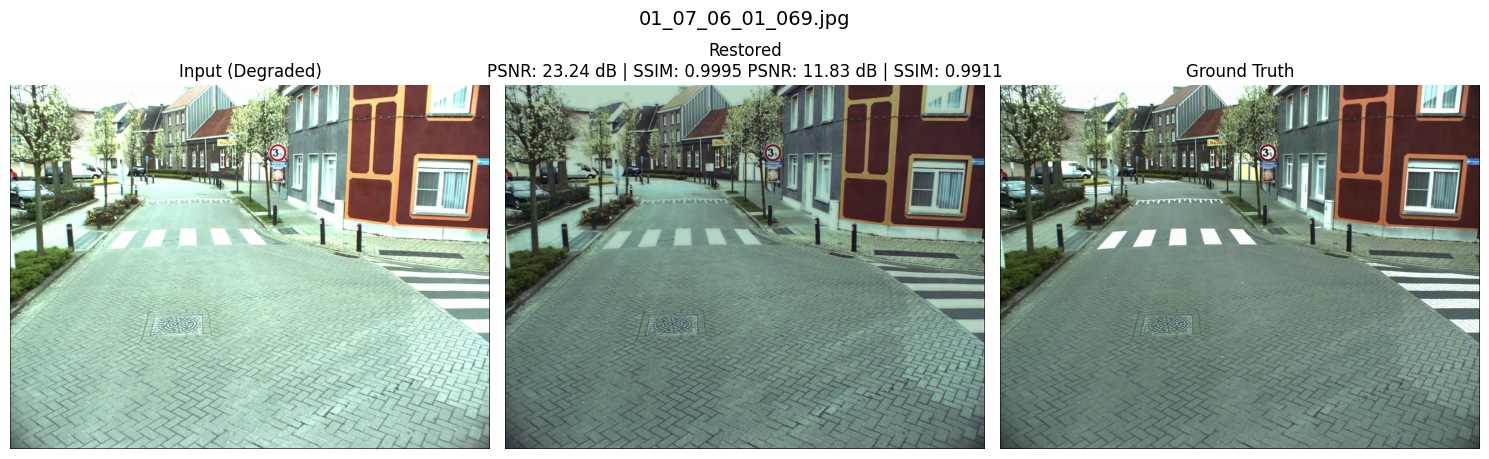

In [ ]:
import matplotlib.pyplot as plt
import torch


batch = next(test_iter)

inp = batch["input"].to(device)     # (1,3,H,W)
tgt = batch["target"].to(device)    # (1,3,H,W)
name = batch["name"][0]


# -------- Pad --------
inp_pad, (h, w) = pad_to_multiple_of_8(inp)
tgt_pad, _ = pad_to_multiple_of_8(tgt)



# Model inference

model.eval()
with torch.no_grad():
    with torch.amp.autocast("cuda", enabled=USE_AMP):
        pred_pad = model(inp_pad).clamp(0, 1)

# -------- Unpad --------
pred = pred_pad[:, :, :h, :w]
tgt  = tgt[:, :, :h, :w]


# Metrics
psnr_val = psnr(pred, tgt).item()
ssim_val = ssim(pred, tgt).item()

psnr_inp = psnr(inp, tgt).item()
ssim_inp = ssim(inp, tgt).item()

print(f"Image: {name}")
print(f"PSNR-PRED : {psnr_val:.2f} dB")
print(f"SSIM-PRED : {ssim_val:.4f}")


# Convert tensors to images
inp_img  = inp[0].cpu().permute(1, 2, 0).numpy()
pred_img = pred[0].cpu().permute(1, 2, 0).numpy()
tgt_img  = tgt[0].cpu().permute(1, 2, 0).numpy()


# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(inp_img)
axes[0].set_title("Input (Degraded)")
axes[0].axis("off")

axes[1].imshow(pred_img)
axes[1].set_title(
    f"Restored\nPSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}"
    + f" PSNR: {psnr_inp:.2f} dB | SSIM: {ssim_inp:.4f}"
)
axes[1].axis("off")

axes[2].imshow(tgt_img)
axes[2].set_title("Ground Truth")
axes[2].axis("off")

plt.suptitle(name, fontsize=14)
plt.tight_layout()
plt.show()